<a href="https://colab.research.google.com/github/darshan320/fake-internship/blob/main/Reliable_Network_Congestion_Prediction_A_Multi_Model_Ensemble_Approach_with_Bootstrap_Sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Set a random seed for reproducibility
np.random.seed(42)

# Number of samples
n_samples = 1000

# 1. Timestamp: Standard datetime
start_date = pd.to_datetime('2023-01-01 00:00:00')
timestamps = pd.date_range(start=start_date, periods=n_samples, freq='min')

# 2. Latency_ms: Float (Range 10ms to 500ms)
latency_ms = np.random.uniform(10, 500, n_samples);

# 3. Packet_Loss_Percentage: Float (Range 0% to 10%)
packet_loss_percentage = np.random.uniform(0, 10, n_samples)

# 4. Bandwidth_Usage_Mbps: Float (Range 10 to 1000 Mbps)
bandwidth_usage_mbps = np.random.uniform(10, 1000, n_samples)

# 5. User_Count: Integer (Range 1 to 200)
user_count = np.random.randint(1, 201, n_samples)

# 6. Is_Congested: Binary (0 or 1)
# Logic: Ensure a correlation where high Latency, high Packet_Loss, and high User_Count typically result in Is_Congested = 1.
# Define thresholds for 'high' values
latency_threshold = 350  # ms
packet_loss_threshold = 7 # %
user_count_threshold = 150 # users

# Initialize Is_Congested to 0
is_congested = np.zeros(n_samples, dtype=int)

# Apply congestion logic
# A simple way to create correlation: if at least 2 of the 3 conditions (high latency, high packet loss, high user count) are met.
# Add some randomness so it's not perfectly deterministic.

for i in range(n_samples):
    congestion_score = 0
    if latency_ms[i] > latency_threshold: congestion_score += 1
    if packet_loss_percentage[i] > packet_loss_threshold: congestion_score += 1
    if user_count[i] > user_count_threshold: congestion_score += 1

    # If at least two conditions are met, set to congested with high probability
    if congestion_score >= 2:
        if np.random.rand() < 0.9: # 90% chance of being congested if conditions are met
            is_congested[i] = 1
        else:
            is_congested[i] = 0 # 10% chance of not being congested even if conditions are met (noise)
    elif congestion_score == 1:
        if np.random.rand() < 0.3: # 30% chance of being congested if one condition is met
            is_congested[i] = 1
        else:
            is_congested[i] = 0
    else: # congestion_score == 0
        if np.random.rand() < 0.05: # 5% chance of being congested even if no conditions are met (noise)
            is_congested[i] = 1
        else:
            is_congested[i] = 0

# Create the DataFrame
data = pd.DataFrame({
    'Timestamp': timestamps,
    'Latency_ms': latency_ms,
    'Packet_Loss_Percentage': packet_loss_percentage,
    'Bandwidth_Usage_Mbps': bandwidth_usage_mbps,
    'User_Count': user_count,
    'Is_Congested': is_congested
})

# Save to CSV
file_path = 'network_congestion_data.csv'
data.to_csv(file_path, index=False)

print(f"Synthetic dataset generated and saved to '{file_path}'")
print(data.head())
print("\nCongestion distribution:")
print(data['Is_Congested'].value_counts())

Synthetic dataset generated and saved to 'network_congestion_data.csv'
            Timestamp  Latency_ms  Packet_Loss_Percentage  \
0 2023-01-01 00:00:00  193.524658                1.851329   
1 2023-01-01 00:01:00  475.850010                5.419009   
2 2023-01-01 00:02:00  368.677031                8.729458   
3 2023-01-01 00:03:00  303.342657                7.322249   
4 2023-01-01 00:04:00   86.449134                8.065611   

   Bandwidth_Usage_Mbps  User_Count  Is_Congested  
0            269.088627         115             0  
1            254.509011          57             0  
2            907.192035          72             1  
3            257.050738           7             0  
4            279.230229         184             1  

Congestion distribution:
Is_Congested
0    655
1    345
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.utils import resample

# Load the dataset
df = pd.read_csv('network_congestion_data.csv')

# Define features (X) and target (y)
X = df[['Latency_ms', 'Packet_Loss_Percentage', 'Bandwidth_Usage_Mbps', 'User_Count']]
y = df['Is_Congested']

# Create three distinct bootstrap samples
n_subsets = 3
bootstrap_subsets_X = []
bootstrap_subsets_y = []

print(f"Generating {n_subsets} bootstrap samples...")
for i in range(n_subsets):
    # Resample with replacement
    X_subsample, y_subsample = resample(X, y, replace=True, n_samples=len(df), random_state=i) # Using i as random_state for distinct samples
    bootstrap_subsets_X.append(X_subsample)
    bootstrap_subsets_y.append(y_subsample)
    print(f"Subset {i+1}: X_subsample shape {X_subsample.shape}, y_subsample shape {y_subsample.shape}")

print("\nFirst 5 rows of the first bootstrap sample (features):")
display(bootstrap_subsets_X[0].head())

print("\nFirst 5 rows of the first bootstrap sample (target):")
display(bootstrap_subsets_y[0].head())

print("\nValue counts for 'Is_Congested' in each bootstrap sample:")
for i, y_subset in enumerate(bootstrap_subsets_y):
    print(f"Subset {i+1}:\n{y_subset.value_counts()}")

Generating 3 bootstrap samples...
Subset 1: X_subsample shape (1000, 4), y_subsample shape (1000,)
Subset 2: X_subsample shape (1000, 4), y_subsample shape (1000,)
Subset 3: X_subsample shape (1000, 4), y_subsample shape (1000,)

First 5 rows of the first bootstrap sample (features):


,Latency_ms,Packet_Loss_Percentage,Bandwidth_Usage_Mbps,User_Count
684,465.394235,1.325247,343.972091,171
559,313.951680,9.000231,505.618025,139
629,133.694103,4.503709,393.772317,182
192,451.204848,3.458831,674.024989,63
835,215.273470,6.564786,920.335714,151



First 5 rows of the first bootstrap sample (target):


,Is_Congested
684,1
559,0
629,0
192,1
835,0



Value counts for 'Is_Congested' in each bootstrap sample:
Subset 1:
Is_Congested
0    678
1    322
Name: count, dtype: int64
Subset 2:
Is_Congested
0    651
1    349
Name: count, dtype: int64
Subset 3:
Is_Congested
0    685
1    315
Name: count, dtype: int64


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Initialize models
knn_model = KNeighborsClassifier(n_neighbors=5) # Example: using 5 neighbors
decision_tree_model = DecisionTreeClassifier(random_state=42)
logistic_regression_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets

# Train KNN on Subset A (bootstrap_subsets_X[0], bootstrap_subsets_y[0])
knn_model.fit(bootstrap_subsets_X[0], bootstrap_subsets_y[0])
print("K-Nearest Neighbors model trained on Subset A.")

# Train Decision Tree on Subset B (bootstrap_subsets_X[1], bootstrap_subsets_y[1])
decision_tree_model.fit(bootstrap_subsets_X[1], bootstrap_subsets_y[1])
print("Decision Tree model trained on Subset B.")

# Train Logistic Regression on Subset C (bootstrap_subsets_X[2], bootstrap_subsets_y[2])
logistic_regression_model.fit(bootstrap_subsets_X[2], bootstrap_subsets_y[2])
print("Logistic Regression model trained on Subset C.")

print("\nAll base models have been trained on their respective bootstrap samples.")

K-Nearest Neighbors model trained on Subset A.
Decision Tree model trained on Subset B.
Logistic Regression model trained on Subset C.

All base models have been trained on their respective bootstrap samples.


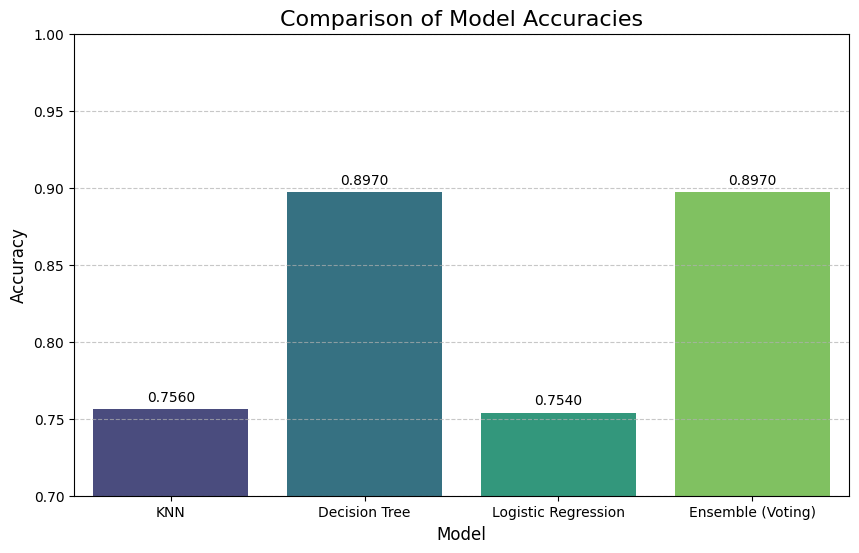

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
import pandas as pd

# Calculate accuracies for individual models
accuracy_knn = accuracy_score(y, knn_model.predict(X))
accuracy_dt = accuracy_score(y, decision_tree_model.predict(X))
accuracy_lr = accuracy_score(y, logistic_regression_model.predict(X))

# Calculate ensemble accuracy here, as it was not defined in this scope
# Make predictions on the entire dataset using the ensemble model
y_pred_ensemble = voting_classifier.predict(X)
accuracy = accuracy_score(y, y_pred_ensemble) # Define 'accuracy' here

models = ['KNN', 'Decision Tree', 'Logistic Regression', 'Ensemble (Voting)']
accuracies = [accuracy_knn, accuracy_dt, accuracy_lr, accuracy]

# Create a DataFrame for easy plotting
accuracy_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

# Plotting the accuracies
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis', hue='Model', legend=False)
plt.title('Comparison of Model Accuracies', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0.7, 1.0) # Set y-axis limit to better visualize differences

# Add accuracy values on top of the bars
for index, row in accuracy_df.iterrows():
    plt.text(index, row['Accuracy'] + 0.005, f"{row['Accuracy']:.4f}", color='black', ha="center")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from sklearn.ensemble import VotingClassifier

# Combine the base models into a Voting Classifier
voting_classifier = VotingClassifier(estimators=[
    ('knn', knn_model),
    ('dt', decision_tree_model),
    ('lr', logistic_regression_model)
], voting='hard') # 'hard' for majority voting

# Train the Voting Classifier on the original dataset (or a new unseen dataset for evaluation)
# For simplicity, we'll use the original full dataset for fitting here, though typically you'd
# use a separate training set if the base models weren't trained on bootstrap samples.
voting_classifier.fit(X, y)

print("Ensemble Voting Classifier created and trained using Hard Voting.")

Ensemble Voting Classifier created and trained using Hard Voting.



--- Ensemble Voting Classifier - Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       655
           1       0.94      0.75      0.83       345

    accuracy                           0.90      1000
   macro avg       0.91      0.86      0.88      1000
weighted avg       0.90      0.90      0.89      1000

Overall Accuracy: 0.8970


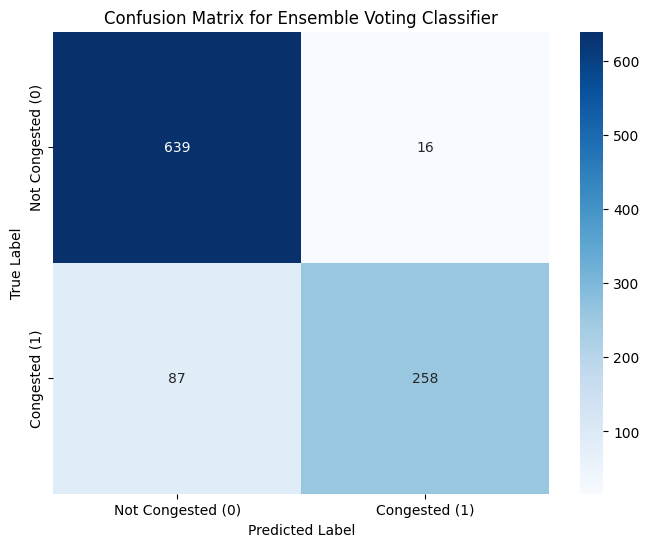

In [ ]:



from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the entire dataset using the ensemble model
y_pred = voting_classifier.predict(X)

# 1. Classification Report
print("\n--- Ensemble Voting Classifier - Classification Report ---")
print(classification_report(y, y_pred))

# 2. Accuracy Score
accuracy = accuracy_score(y, y_pred)
print(f"Overall Accuracy: {accuracy:.4f}")

# 3. Confusion Matrix Visualization
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Congested (0)', 'Congested (1)'],
            yticklabels=['Not Congested (0)', 'Congested (1)'])
plt.title('Confusion Matrix for Ensemble Voting Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

/tmp/ipykernel_5945/3522013868.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Is_Congested', data=df, palette='viridis')


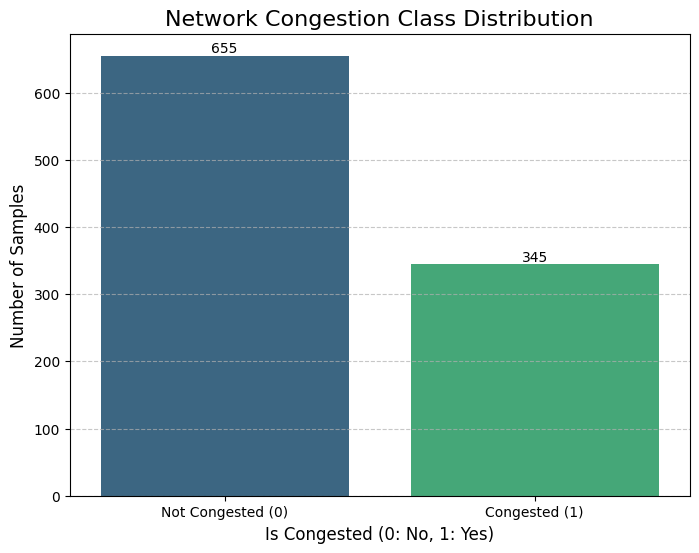

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the count plot
plt.figure(figsize=(8, 6))
sns.countplot(x='Is_Congested', data=df, palette='viridis')

# Add title and labels
plt.title('Network Congestion Class Distribution', fontsize=16)
plt.xlabel('Is Congested (0: No, 1: Yes)', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks([0, 1], ['Not Congested (0)', 'Congested (1)'])

# Display exact count values on top of each bar
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                       textcoords='offset points')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Evaluating Individual Base Models